In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import KFold

from scipy.stats import ks_2samp

from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("datasets/improved_credit_risk.csv")

In [3]:
df.drop(columns=["Age"], inplace=True)

In [4]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [5]:
cat_cols = ["Payment_of_Min_Amount", "Credit_Mix", "Payment_Behaviour", "Borrower_Tier"]

df[cat_cols] = df[cat_cols].astype("category")

In [7]:
X = df.drop("Default_Flag", axis=1)
y = df["Default_Flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [10]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=300,
    learning_rate=0.05,
    enable_categorical=True,
    tree_method="hist",
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [13]:
y_pred_proba = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_pred_proba)

0.6132248544913028

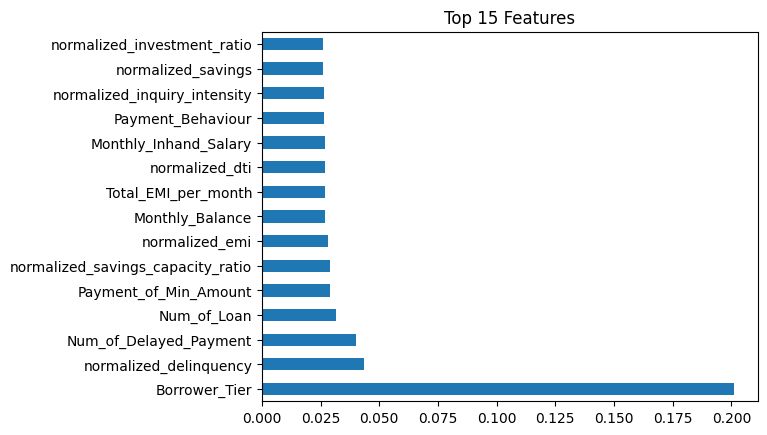

In [16]:
important_features = pd.Series(model.feature_importances_, index=X.columns)

important_features.nlargest(15).plot(kind="barh")
plt.title("Top 15 Features")

plt.show()

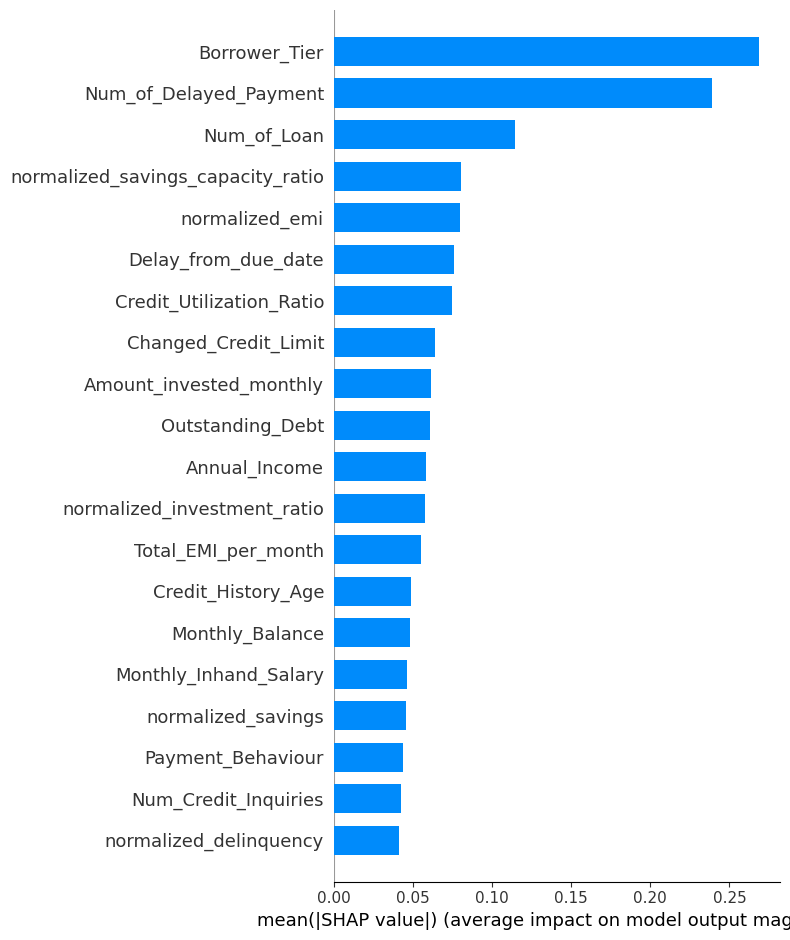

In [18]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar")

In [20]:
calib_model = CalibratedClassifierCV(model, method="isotonic", cv=3)
calib_model.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,3
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [21]:
y_pred_proba = calib_model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_pred_proba)

0.6196011804307846

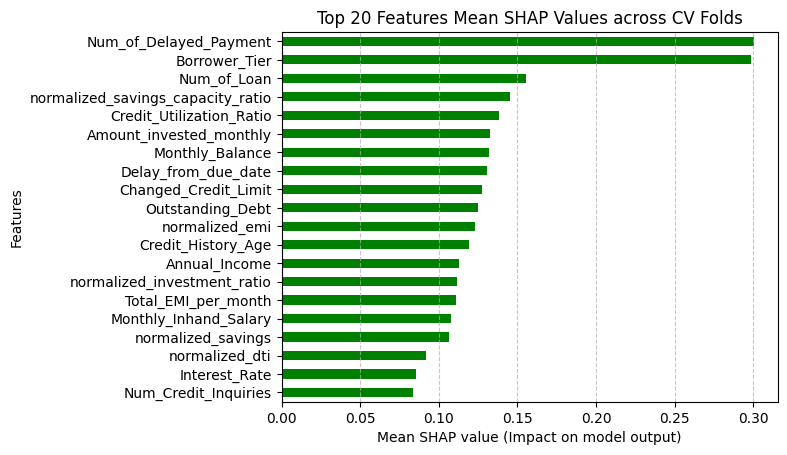

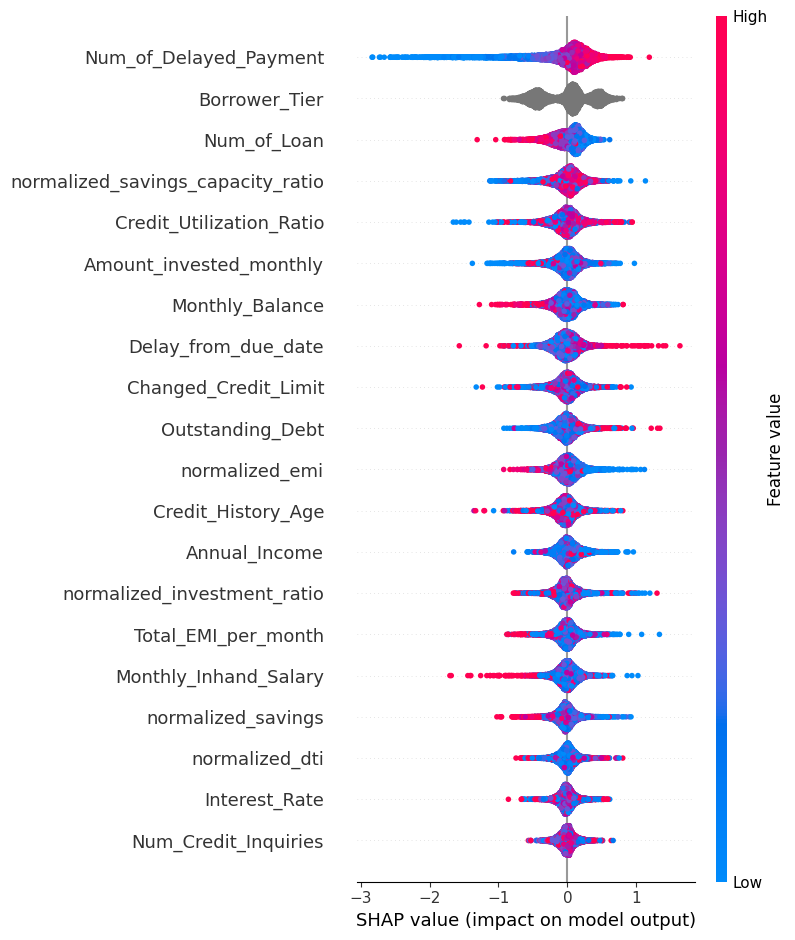

In [24]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X)])])

In [26]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(enable_categorical=True, tree_method="hist")
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.5960019872801726, 0.5982120562804499, 0.6280274599542334, 0.6090112109424306, 0.6057722860722914, 0.5675587101193393, 0.5872202294489076]
Mean AUC: 0.5988291342996892
KS per fold: [np.float64(0.1636790604238091), np.float64(0.17325459180414496), np.float64(0.20825324180015256), np.float64(0.17188486121151617), np.float64(0.1833306354430835), np.float64(0.11633667751211994), np.float64(0.14952716924080278)]
Mean KS: 0.1666094624908041
